# 09 — Final evaluation: detector comparison, official test, discussion
A4 detector table over the 5 pre-registered seeds + the score-correlation matrix,
the VAE row (A4b), the once-only official test scoring,
and a short critical discussion.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.loaders import prepare, load, load_rul, SENSORS, SEEDS, HEALTHY_RUL
from src.scores import GeometricModel
from src import metrics
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

## A4 — Detector comparison + score-correlation matrix (5 seeds, FD004 no-buffer)
VAE row (A4b). Architecture 14-32-3-32-14, fixed in advance; β grid
on seed 42, table row at β=1 (fixed a priori — the standard ELBO)
over the 5 pre-registered seeds. Requires `torch` (CPU is enough, see requirements.txt).

In [2]:
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import HistGradientBoostingClassifier
rows, corr_scores = [], None
for seed in SEEDS:
    d = prepare('FD004', seed=seed)
    gm = GeometricModel().fit(d['fit'])
    sc_f, sc_v = gm.score(d['fit']), gm.score(d['val'])
    hm = (d['fit'].rul > HEALTHY_RUL).values
    S = {'z-s11': d['val'].s11.abs().values,
         'position': sc_v['pos'].values, 'velocity': sc_v['vel'].values,
         'net-displacement': sc_v['net'].values}

    # Mahalanobis on the 14 raw (normalized) sensors — no PCA (isolates what latent adds)
    H_raw = d['fit'][d['fit'].rul > HEALTHY_RUL][SENSORS]
    VI_raw = np.linalg.inv(np.cov(H_raw.T.values) + 1e-6 * np.eye(len(SENSORS)))
    dlt = d['val'][SENSORS].values - H_raw.mean().values
    S['Mahal-sensors'] = np.sqrt(np.einsum('ij,jk,ik->i', dlt, VI_raw, dlt))

    # LOF on the PCA latent space (healthy fit cycles as reference)
    H_lat = gm.latent(d['fit'][d['fit'].rul > HEALTHY_RUL])
    sub = np.random.RandomState(seed).choice(len(H_lat), min(15000, len(H_lat)), replace=False)
    lof = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(H_lat[sub])
    S['LOF-latent'] = -lof.score_samples(gm.latent(d['val']))

    # kNN on the PCA latent space
    H = gm.latent(d['fit'][d['fit'].rul > HEALTHY_RUL])
    sub_knn = np.random.RandomState(0).choice(len(H), min(15000, len(H)), replace=False)
    nn = NearestNeighbors(n_neighbors=10).fit(H[sub_knn])
    S['kNN-latent'] = nn.kneighbors(gm.latent(d['val']))[0][:, -1]

    iso = IsolationForest(n_estimators=200, random_state=seed).fit(sc_f.loc[hm, ['pos', 'vel', 'net']])
    S['IForest-fusion'] = -iso.score_samples(sc_v[['pos', 'vel', 'net']])
    clf = HistGradientBoostingClassifier(random_state=seed).fit(d['fit'][SENSORS], (d['fit'].rul < 30).astype(int))
    S['skyline (supervised)'] = clf.predict_proba(d['val'][SENSORS])[:, 1]
    rows.append({k: metrics.auroc(v, d['val'].rul, use_buffer=False) for k, v in S.items()})
    if seed == 42:
        corr_scores = pd.DataFrame(S)
a4 = pd.DataFrame(rows).agg(['mean', 'std']).T.round(3).sort_values('mean', ascending=False)
a4.to_csv('../results/tables/08_A4_detectors.csv'); a4

,mean,std
skyline (supervised),0.987,0.002
position,0.977,0.002
kNN-latent,0.977,0.001
IForest-fusion,0.976,0.003
Mahal-sensors,0.968,0.001
net-displacement,0.962,0.003
z-s11,0.959,0.009
LOF-latent,0.918,0.049
velocity,0.795,0.009


In [3]:
# A4b — VAE detector row (mandatory). 14-32-3-32-14, trained on healthy fit cycles only.
# Anomaly score = negative ELBO (reconstruction + KL), the canonical VAE score.
# Expected outcome (pre-declared): parity with position — a (near-)linear VAE on 14
# z-scored sensors learns essentially probabilistic PCA, so its KL term measures the
# same Mahalanobis-type distance as the position score. The decomposition below
# verifies this empirically.
import torch
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, d=14, h=32, k=3):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d, h), nn.ReLU())
        self.mu, self.lv = nn.Linear(h, k), nn.Linear(h, k)
        self.dec = nn.Sequential(nn.Linear(k, h), nn.ReLU(), nn.Linear(h, d))
    def forward(self, x):
        e = self.enc(x)
        mu, lv = self.mu(e), self.lv(e)
        z = mu + torch.randn_like(mu) * (0.5 * lv).exp()
        return self.dec(z), mu, lv

def train_vae(X, beta=1.0, epochs=25, bs=256, seed=0, lr=1e-3):
    torch.manual_seed(seed)
    m = VAE(X.shape[1])
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    Xt = torch.tensor(X, dtype=torch.float32)
    for _ in range(epochs):
        for idx in torch.randperm(len(Xt)).split(bs):
            xb = Xt[idx]
            xr, mu, lv = m(xb)
            rec = ((xr - xb) ** 2).sum(1).mean()
            kld = (-0.5 * (1 + lv - mu ** 2 - lv.exp()).sum(1)).mean()
            loss = rec + beta * kld
            opt.zero_grad(); loss.backward(); opt.step()
    return m

@torch.no_grad()
def vae_terms(m, X):
    """Deterministic per-cycle scores: reconstruction (posterior mean), KL, neg-ELBO."""
    Xt = torch.tensor(X, dtype=torch.float32)
    e = m.enc(Xt)
    mu, lv = m.mu(e), m.lv(e)
    rec = ((m.dec(mu) - Xt) ** 2).sum(1)
    kld = -0.5 * (1 + lv - mu ** 2 - lv.exp()).sum(1)
    return rec.numpy(), kld.numpy(), (rec + kld).numpy()

# beta grid, seed 42 — reported transparently, NOT used for selection
d42 = prepare('FD004', seed=42)
H42 = d42['fit'][d42['fit'].rul > HEALTHY_RUL][SENSORS].values
Xv42 = d42['val'][SENSORS].values
grid = {}
for beta in [0.1, 1.0, 4.0]:
    m = train_vae(H42, beta=beta, seed=42)
    grid[beta] = round(metrics.auroc(vae_terms(m, Xv42)[2], d42['val'].rul, use_buffer=False), 3)
print('beta grid, neg-ELBO score (seed 42, FD004 no-buffer AUROC):', grid)

# score decomposition at beta=1 (seed 42): the KL term IS the position score, empirically
rec, kld, elbo = vae_terms(train_vae(H42, beta=1.0, seed=42), Xv42)
for nm, s in [('reconstruction', rec), ('KL', kld), ('neg-ELBO', elbo)]:
    print('  %-15s AUROC = %.3f' % (nm, metrics.auroc(s, d42['val'].rul, use_buffer=False)))


# Robustness of the A4b row (seed 42, beta=1): architecture and training grid.
# Design check, NOT tuning — nothing below was used for selection; the table row
# above keeps the pre-declared 14-32-3-32-14, beta=1, 25 epochs.
def elbo_auroc(h=32, k=3, epochs=25, lr=1e-3, bs=256):
    torch.manual_seed(42)
    m = VAE(14, h, k)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    Xt = torch.tensor(H42, dtype=torch.float32)
    for _ in range(epochs):
        for idx in torch.randperm(len(Xt)).split(bs):
            xb = Xt[idx]
            xr, mu, lv = m(xb)
            loss = ((xr - xb) ** 2).sum(1).mean() + (-0.5 * (1 + lv - mu ** 2 - lv.exp()).sum(1)).mean()
            opt.zero_grad(); loss.backward(); opt.step()
    return metrics.auroc(vae_terms(m, Xv42)[2], d42['val'].rul, use_buffer=False)

print('architecture sensitivity (h, k):')
for h, k in [(32, 3), (16, 3), (64, 3), (32, 2), (32, 5)]:
    print('  h=%-3d k=%d : %.3f' % (h, k, elbo_auroc(h=h, k=k)))
print('training sensitivity (epochs, lr, batch):')
for kw in [dict(epochs=10), dict(epochs=50), dict(lr=3e-4), dict(lr=3e-3), dict(bs=128)]:
    print('  %-16s: %.3f' % (', '.join(f'{a}={b}' for a, b in kw.items()), elbo_auroc(**kw)))

# A4b table row: neg-ELBO, beta=1 (fixed a priori), 5 pre-registered seeds
aus = []
for seed in SEEDS:
    d = prepare('FD004', seed=seed)
    Hs = d['fit'][d['fit'].rul > HEALTHY_RUL][SENSORS].values
    m = train_vae(Hs, beta=1.0, seed=seed)
    aus.append(metrics.auroc(vae_terms(m, d['val'][SENSORS].values)[2],
                             d['val'].rul, use_buffer=False))
a4.loc['VAE-ELBO (A4b)'] = [np.mean(aus), np.std(aus, ddof=1)]
a4 = a4.sort_values('mean', ascending=False).round(3)
a4.to_csv('../results/tables/08_A4_detectors.csv')
a4


beta grid, neg-ELBO score (seed 42, FD004 no-buffer AUROC): {0.1: 0.977, 1.0: 0.969, 4.0: 0.961}
  reconstruction  AUROC = 0.834
  KL              AUROC = 0.977
  neg-ELBO        AUROC = 0.969
architecture sensitivity (h, k):
  h=32  k=3 : 0.969
  h=16  k=3 : 0.969
  h=64  k=3 : 0.971
  h=32  k=2 : 0.970
  h=32  k=5 : 0.968
training sensitivity (epochs, lr, batch):
  epochs=10       : 0.970
  epochs=50       : 0.970
  lr=0.0003       : 0.972
  lr=0.003        : 0.969
  bs=128          : 0.969


                       mean    std
skyline (supervised)  0.987  0.002
position              0.977  0.002
kNN-latent            0.977  0.001
IForest-fusion        0.976  0.003
Mahal-sensors         0.968  0.001
VAE-ELBO (A4b)        0.965  0.003
net-displacement      0.962  0.003
z-s11                 0.959  0.009
LOF-latent            0.918  0.049
velocity              0.795  0.009

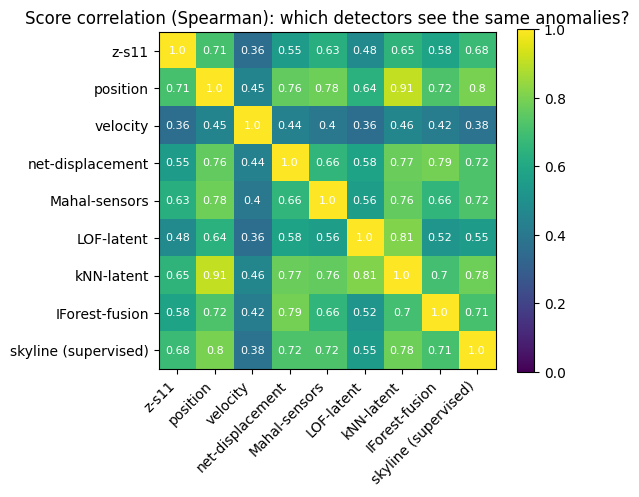

In [4]:
cm = corr_scores.corr(method='spearman').round(2)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, vmin=0, vmax=1, cmap='viridis')
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=45, ha='right')
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.columns)
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, cm.iloc[i, j], ha='center', va='center', c='w', fontsize=8)
plt.colorbar(im); ax.set_title('Score correlation (Spearman): which detectors see the same anomalies?')
plt.tight_layout(); plt.savefig('../results/figures/08_score_corr.png', dpi=120); plt.show()

## Official test files — touched ONCE
Score the official `test_FD004.txt` engines (trajectories truncated before failure) and check:
does the detector flag the engines that the RUL file says are close to failure?

In [5]:
d = prepare('FD004', seed=42)
gm = GeometricModel().fit(d['fit'])
te = load('FD004', 'test'); true_rul = load_rul('FD004')
te = d['regime_assigner'].assign(te)
te['rul'] = 999  # unknown during scoring; only used for grouping below
ten = d['normalizer'].transform(te)
sc_te = gm.score(ten)
last = ten.groupby('unit').tail(1).index
s_last = sc_te.loc[last, 'net'].values
flag = s_last >= np.quantile(gm.score(d['cal'][d['cal'].rul > HEALTHY_RUL])['net'], 0.99)
near = true_rul <= 30
print('official test engines: %d | near-failure (true RUL<=30): %d' % (len(true_rul), near.sum()))
print('flagged among near-failure: %.2f | flagged among healthy-ish (RUL>100): %.2f' %
      (flag[near].mean(), flag[true_rul > 100].mean()))

official test engines: 248 | near-failure (true RUL<=30): 53
flagged among near-failure: 1.00 | flagged among healthy-ish (RUL>100): 0.08


# Discussion
1. **What mattered most: preprocessing.** A1 shows regime normalization moves AUROC ~+0.4 on
   FD004 — larger than any detector swap in A4. The methodological lesson of the project.
2. **Circularity, acknowledged and mitigated.** Labels derive from RUL; mitigations: buffer-band +
   label-free Spearman + the conformal layer, whose false-alarm guarantee uses no labels at all.
3. **Negative results as method.** Arc length (age proxy, corr 0.996 with cycle) and raw velocity
   (AUROC ≈ 0.5) failed as designed; the diagnoses are the project's core reasoning.
4. **Limitations.** Simulated data; smooth single-fault degradation; no per-unit fault labels in
   FD003 (cluster quality substitutes); conformal exchangeability imperfect under regime mixing
   (per-regime calibration mitigates — notebook 07).
5. **Claims.** Supported: geometric scores detect degradation tens of cycles before failure
   with controlled false alarms; fault modes separate as directions. Speculative: velocity onset =
   physical fault initiation.